# PSD for OU process


This notebook compares the PSD defined by an OU process with in the PSD that is typically used in pulsar timing for the GW background.

We then use these comparisons to set approximate, order-of-magnitude estimates on typical values of our model parameters.

The "traditional" PSD typically used by pulsar people is a standard power law:

$$ P(f) = \frac{A^2}{12 \pi^2} \left( \frac{f}{f_{\text{yr}}}\right)^{-\alpha} [\text{Units: } \text{yr}^{3}]$$ 

Note that sometimes the amplitude is defined differently, with the $12\pi^2$ factor being absorbed, e.g Equation 14 of [Chamberlin et al. 2014](https://arxiv.org/abs/1410.8256), although the modern convention seems to be to leave the factor unabsorbed, e.g. [Reardon et al. 2023](https://arxiv.org/abs/2306.16215). The convention is also to have the amplitude $A$ be _dimensionless_ and the PSD to have units of yr$^3$. When people quote the PSD amplitude in the literature they are referring to this dimensionless amplitude - this will be important to note later w.r.t unit conversion. 

Some other useful literature:
* https://github.com/vallis/libstempo/blob/master/libstempo/toasim.py#L298 
* Equation 7.13 (mind the units!) from https://arxiv.org/pdf/2105.13270 
* Equation 1 in https://arxiv.org/pdf/2306.16229


---

# Derivation of PSD for GW-induced residual fuctuations from the Ornstein-Uhlenbeck Process

## Starting with the Ornstein-Uhlenbeck SDE
We begin with the Ornstein-Uhlenbeck stochastic differential equation:

$$\frac{dx}{dt} = -\gamma x + \chi(t;\sigma)$$

where $\chi(t;\sigma)$ is white noise with standard deviation $\sigma$.

## PSD of the Ornstein-Uhlenbeck process
Converting to the frequency domain using the Fourier transform:

$$i\omega\tilde{x}(\omega) = -\gamma\tilde{x}(\omega) + \tilde{\chi}(\omega)$$

Solving for $\tilde{x}(\omega)$:

$$\tilde{x}(\omega) = \frac{\tilde{\chi}(\omega)}{i\omega + \gamma}$$

The PSD of $x$ is then:

$$S_x(\omega) = |\tilde{x}(\omega)|^2 = \frac{|\tilde{\chi}(\omega)|^2}{|i\omega + \gamma|^2} = \frac{\sigma^2}{\omega^2 + \gamma^2}$$

Converting to frequency $f$ where $\omega = 2\pi f$:

$$S_x(f) = \frac{\sigma^2}{(2\pi f)^2 + \gamma^2}$$

This can be rewritten as:

$$S_x(f) = \frac{\sigma^2/\gamma^2}{1 + (f/f_c)^2}$$

where $f_c = \gamma/(2\pi)$ is the corner frequency.

## PSD of timing residuals $r(t)$
Given that $\frac{dr}{dt} = x$, in the frequency domain:

$$\tilde{x}(f) = i2\pi f \cdot \tilde{r}(f)$$

For power spectral densities, this means:

$$S_x(f) = (2\pi f)^2 \cdot S_{r}(f)$$

Rearranging and substituting the expression for $S_x(f)$:

$$S_{r}(f) = \frac{S_x(f)}{(2\pi f)^2} = \frac{\sigma^2/\gamma^2}{(2\pi f)^2 \cdot [1 + (f/f_c)^2]}$$

Simplifying:

$$S_{r}(f) = \frac{\sigma^2}{\gamma^2} \cdot \frac{1}{(2\pi f)^2 [1 + (f/f_c)^2]}$$

This PSD has:
- A $1/f^2$ behavior at low frequencies ($f \ll f_c$)
- A $1/f^4$ behavior at high frequencies ($f \gg f_c$)
- Units of s²/Hz

In [2]:
import numpy as np



# Constants and unit conversions
seconds_per_year = 365.25 * 24 * 60 * 60  # seconds in a year

def power_law_psd(f, A, alpha):
    """Traditional PSD model: P(f) = A^2/(12*pi^2) * (f/f_ref)^(-alpha) [yr^3]"""

    #First calculate in yr^{3}
    f_ref = 1/seconds_per_year
    psd_yr = (A**2 / (12 * np.pi**2)) * (f / f_ref)**(-alpha) 

    # Converting from yr^3 to s^3 for consistency
    return psd_yr * seconds_per_year**3


def ou_psd(f, sigma, gamma):
    """Calculates the PSD of timing residuals assuming normalized frequency deviations follow an Ornstein-Uhlenbeck process.

    This function models the Power Spectral Density (PSD) of timing residuals r(t)
    under the assumption that their time derivative, which corresponds to the
    normalized frequency deviation x(t) = δν(t)/ν₀ = dr/dt, follows an
    Ornstein-Uhlenbeck (OU) process.

    The underlying OU stochastic differential equation (SDE) is modeled as:
    dx/dt = -γ * x(t) + χ(t)
    where χ(t) is white noise with a flat PSD S_χ(f) = σ².

    The resulting PSD of the timing residuals r(t) is given by:
    S_r(f) = S_x(f) / (2πf)²
           = [ σ² / ((2πf)² + γ²) ] / (2πf)²
           = σ² / ( (2πf)² * (γ² + (2πf)²) )
           = (σ² / γ²) / ( (2πf)² * (1 + (f/f_c)²) )

    where f_c = γ / (2π) is the corner frequency.

    Parameters
    ----------
    f : array_like
        Frequency(ies) at which to evaluate the PSD (units: Hz or s⁻¹).
        Should not contain f=0, as the function involves division by f.
    sigma : float
        Parameter related to the strength of the white noise driving the OU
        process for x = δν/ν₀. Specifically, σ² is the PSD of the driving
        white noise χ(t) (units of σ²: s⁻¹ or Hz). Thus, sigma has units of s⁻½.
    gamma : float
        Damping or relaxation rate of the OU process (units: s⁻¹).

    Returns
    -------
    psd : array_like
        The Power Spectral Density of the timing residuals r(t)
        (units: s³ or s² / Hz).

    Notes
    -----
    - The corner frequency f_c (Hz) is implicitly defined as f_c = γ / (2π).
    - This model assumes the OU process acts on the dimensionless normalized
      frequency deviations x = δν/ν₀.
    - Requires numpy imported as np.
    - Warning: This function will produce errors or Inf/NaN if f contains zero.
    """
    # Calculate corner frequency
    fc = gamma / (2.0 * np.pi)

    # Calculate PSD
    psd = (sigma**2 / (gamma**2 * (2.0 * np.pi)**2)) * \
          (1.0 / (f**2 * (1.0 + (f / fc)**2)))

    return psd



### Gravitational waves.


f_week: 1.65e-06 Hz
f_month: 3.86e-07 Hz
f_fifteen_yr: 2.11e-09 Hz


Text(1.5915494309189535e-10, 1e-20, 'f_knee')

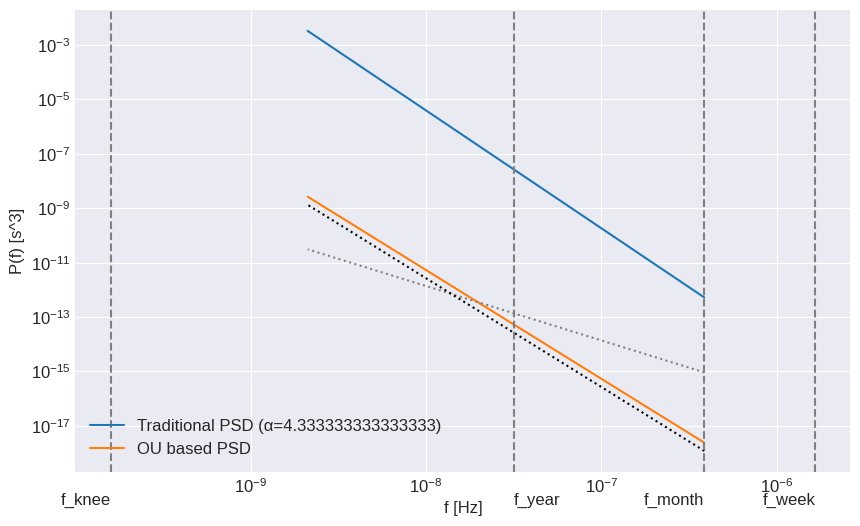

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogFormatter
import matplotlib as mpl


f_week = 1/604800.0
f_month = 1/(30.0*24*60*60)
f_year = 1 / (1.0 * 31536000.0) # Let's use 1 / (1 year) for clarity? Or keep original? Let's keep original for now.
f_fifteen_yr = 1/(15*31536000.0) # More descriptive name

print(f"f_week: {f_week:.2e} Hz")
print(f"f_month: {f_month:.2e} Hz")
print(f"f_fifteen_yr: {f_fifteen_yr:.2e} Hz")

# Use f_month and f_fifteen_yr for the plotting range ends
f_range = np.logspace(np.log10(f_month), np.log10(f_fifteen_yr), 100)

#PSD
A = 1e-14  # Example amplitude. https://github.com/ipta/mdc2/blob/master/group1/group1_gw_parameters.json
alpha = 13/3
psd_trad = power_law_psd(f_range,A,alpha) #units of s^3

#OU
gamma = 1e-9
ha = 1e-15
sigma2 = ha**2 * gamma / 12 # not strictly true, but for order of magnitude estimates it's fine.
sigma = np.sqrt(sigma2)
psd_ou = ou_psd(f=f_range,sigma=sigma,gamma=gamma) 



# --- Add Power Law Guide Lines ---
# Choose a reference point - let's use the middle of the frequency range
mid_index = len(f_range) // 2
f0 = f_range[mid_index]
# Anchor the guides near the OU curve value at f0 for visual reference
P0 = psd_ou[mid_index]

# Calculate P(f) proportional to f^-2 passing through (f0, P0*2) for slight offset
psd_f_minus_2 = (P0*2) * (f_range / f0)**(-2)
# Calculate P(f) proportional to f^-4 passing through (f0, P0/2) for slight offset
psd_f_minus_4 = (P0/2) * (f_range / f0)**(-4)
# ----------------------------------













#Plot
# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
mpl.rcParams['figure.figsize'] = [10, 6]
mpl.rcParams['font.size'] = 12


plt.loglog(f_range, psd_trad, label=f'Traditional PSD (α={alpha})')
plt.loglog(f_range, psd_ou, label=f'OU based PSD')
plt.legend()
plt.xlabel('f [Hz]')
plt.ylabel('P(f) [s^3]')



# Plot the guide lines
plt.loglog(f_range, psd_f_minus_2, label='$f^{-2}$ guide', color='gray', linestyle=':', linewidth=1.5)
plt.loglog(f_range, psd_f_minus_4, label='$f^{-4}$ guide', color='black', linestyle=':', linewidth=1.5)








plt.axvline(f_week,color='0.5',linestyle='--')
plt.text(f_week,1e-20,'f_week',ha='right',va='bottom')

plt.axvline(f_year,color='0.5',linestyle='--')
plt.text(f_year,1e-20,'f_year',ha='left',va='bottom')


plt.axvline(f_month,color='0.5',linestyle='--')
plt.text(f_month,1e-20,'f_month',ha='right',va='bottom')


f_knee = gamma / (2*np.pi)
plt.axvline(f_knee,color='0.5',linestyle='--')
plt.text(f_knee,1e-20,'f_knee',ha='right',va='bottom')
